<a href="https://colab.research.google.com/github/Edgar121207/MSCI151_Coursework5_Muhammad_Edgar_Al_Farizi/blob/main/CW5_Edgar_Al_Farizi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Data Preparation**

In [277]:
!pip install pulp
from IPython.core.display import publish_display_data
import pulp as pl
from collections import defaultdict
import os
import csv


In [278]:
baristas=["Max","Jiwa","Fore","Donna","Paul"]
days= list(range(1,7))
blocks=list(range(1,5))
H=4
cost={"Max":50000,"Jiwa":50000,"Fore":50000,"Donna":150000,"Paul":150000}
etype={"Max":"P","Jiwa":"P","Fore":"P","Donna":"F","Paul":"F"}
minweekly={"Max":12,"Jiwa":12,"Fore":12,"Donna":36,"Paul":36}

In [279]:
avail={("Max",1):8,("Max",2):8,("Max",3):8,("Max",4):0,("Max",5):8,("Max",6):4,("Max",7):4,("Jiwa",1):4,("Jiwa",2):4,("Jiwa",3):8,("Jiwa",4):8,("Jiwa",5):0,("Jiwa",6):4,("Jiwa",7):0,("Fore",1):8,("Fore",2):0,("Fore",3):8,("Fore",4):8,("Fore",5):8,("Fore",6):8,("Fore",7):0,("Donna",1):12,("Donna",2):12,("Donna",3):12,("Donna",4):12,("Donna",5):12,("Donna",6):12,("Donna",7):8,("Paul",1):12,("Paul",2):8,("Paul",3):12,("Paul",4):12,("Paul",5):8,("Paul",6):12,("Paul",7):12,}


In [280]:
DAY_NAME={1:"Monday",2:"Tuesday",3:"Wednesday",4:"Thursday",5:"Friday",6:"Saturday",7:"Sunday"}
BLOCK_NAME={1:"07:00-11:00",2:"11:00-15:00",3:"15:00-19:00",4:"19:00-23:00"}

##**Decision Variables**

In [281]:
y = pl.LpVariable.dicts("Assign",
                        ((o, d, b) for o in baristas for d in days for b in blocks),
                        lowBound=0, upBound=1, cat='Binary')

##Extra Function

In [282]:
def build_staffing_model(baristas, days, blocks, H, cost, avail, etype, minWeekly, allow_blocks=None, name="Staffing", sense=pl.LpMinimize):
    """
    Build baseline staffing model (flat keys y[(o,d,b)]).
    """
    model = pl.LpProblem(name, sense) # Corrected assignment

    if allow_blocks is None:
        allow_blocks = {d: set(blocks) for d in days}
    else:
        allow_blocks = {d: set(bs) for d, bs in allow_blocks.items()}

    # Define decision variables 'y' within the function
    y = pl.LpVariable.dicts("Assign",
                            ((o, d, b) for o in baristas for d in days for b in allow_blocks[d]), # Use allow_blocks here
                            lowBound=0, upBound=1, cat='Binary')

    # Add Coverage constraints
    for d in days:
        for b in allow_blocks[d]:
          model += pl.lpSum(y[(o, d, b)] for o in baristas) >= 1, f"cover_d{d}_b{b}"

    # Add Per-day availability (hours) and contractual block caps constraints
    for o in baristas:
        for d in days:
            # availability limit
            model += H * pl.lpSum(y[(o, d, b)] for b in allow_blocks[d]) <= avail[(o, d)], f"avail_{o}_{d}"
            # contractual daily block cap
            cap = 2 if etype[o] == "P" else 3
            model += pl.lpSum(y[(o, d, b)] for b in allow_blocks[d]) <= cap, f"blockCap_{o}_{d}"

    # Add Weekly minimum hours constraints
    for o in baristas:
        constraint_name = f"minweekly{o}"
        # No need to check if constraint exists, as we are building a new model from scratch each time
        model += H * pl.lpSum(y[(o, d, b)] for d in days for b in allow_blocks[d]) >= minWeekly[o], constraint_name # Use minWeekly parameter

    # Add Objective function
    model += pl.lpSum(y[(o, d, b)] * H * cost[o] for o in baristas for d in days for b in allow_blocks[d]), "Total_Cost" # Use allow_blocks for objective sum

    return model, y, allow_blocks # Return the constructed model, y, and allow_blocks

In [283]:
model = pl.LpProblem("Staffing", pl.LpMinimize)
print("Variable 'moidel' defined as a PuLP problem instance.")

Variable 'moidel' defined as a PuLP problem instance.


In [284]:
minWeekly_default = minweekly
print(f"minWeekly_default defined as: {minWeekly_default}")

allow_blocks = {d: set(blocks) for d in days}
print(f"allow_blocks defined for all days and blocks: {allow_blocks}")

minWeekly_default defined as: {'Max': 12, 'Jiwa': 12, 'Fore': 12, 'Donna': 36, 'Paul': 36}
allow_blocks defined for all days and blocks: {1: {1, 2, 3, 4}, 2: {1, 2, 3, 4}, 3: {1, 2, 3, 4}, 4: {1, 2, 3, 4}, 5: {1, 2, 3, 4}, 6: {1, 2, 3, 4}}


##**Constraints**

Coverage

In [285]:
for d in days:
        for b in allow_blocks[d]:
          model += pl.lpSum(y[(o, d, b)] for o in baristas) >= 1, f"cover_d{d}_b{b}"

Per-day availability (hours) and contractual block caps

In [286]:
 for o in baristas:
        for d in days:
            # availability limit
            model += H * pl.lpSum(y[(o, d, b)] for b in allow_blocks[d]) <= avail[(o, d)], f"avail_{o}_{d}"
            # contractual daily block cap
            cap = 2 if etype[o] == "P" else 3
            model += pl.lpSum(y[(o, d, b)] for b in allow_blocks[d]) <= cap, f"blockCap_{o}_{d}"

Weekly minimum hours

In [287]:
for o in baristas:
        constraint_name = f"minweekly{o}"
        # Check if the constraint already exists and remove it to avoid overlapping names error
        if constraint_name in model.constraints:
            del model.constraints[constraint_name]
        model += H * pl.lpSum(y[(o, d, b)] for d in days for b in allow_blocks[d]) >= minweekly[o], constraint_name

In [288]:
def extract_results(model, y, baristas, days, blocks, allow_blocks, H, cost):
    """
    Extract solver status, objective, hours per barista, and schedule (daily x block).
    """
    status = pl.LpStatus[model.status]
    fairness_gap = pl.value(model.objective) # This is the objective value, which is Hmax-Hmin for fairness

    hours_by_barista = {o: 0 for o in baristas}
    barista_weekly_cost = {o: 0 for o in baristas} # Initialize barista weekly cost
    schedule = defaultdict(lambda: defaultdict(list))  # schedule[d][b] -> list of baristas

    for o in baristas:
        for d in days:
            for b in allow_blocks[d]:
                val = y[(o, d, b)].value()
                if val is not None and val > 0.5:
                    hours_by_barista[o] += H
                    barista_weekly_cost[o] += H * cost[o] # Calculate cost per barista
                    schedule[d][b].append(o)

    # Calculate the actual monetary total cost from barista_weekly_cost
    monetary_total_cost = sum(barista_weekly_cost.values())

    return status, fairness_gap, hours_by_barista, barista_weekly_cost, schedule, monetary_total_cost # Return new cost and monetary total

##**Objective**

In [289]:
model += pl.lpSum(y[(o, d, b)] * H * cost[o] for o in baristas for d in days for b in blocks), "Total_Cost"

##**Model**

In [290]:
status_base, base_cost, base_hours, barista_weekly_cost_base, base_sched = solve_baseline()
print_summary("BASELINE (open 07:00–23:00)", status_base, base_cost, base_hours, base_sched)
save_schedule_csv("results/baseline_schedule.csv", base_hours, base_sched, days, blocks)


BASELINE (open 07:00–23:00)
Solver status: Optimal
Total weekly cost (IDR): 12,600,000

Weekly hours per barista:
  - Max   : 12 hours

Daily × Block schedule:
  - Jiwa  : 12 hours

Daily × Block schedule:
  - Fore  : 12 hours

Daily × Block schedule:
  - Donna : 36 hours

Daily × Block schedule:
  - Paul  : 36 hours

Daily × Block schedule:
  Monday:
    [07:00-11:00] → Jiwa
    [11:00-15:00] → Max
    [15:00-19:00] → Paul
    [19:00-23:00] → Paul
  Tuesday:
    [07:00-11:00] → Donna, Paul
    [11:00-15:00] → Donna
    [15:00-19:00] → Donna
    [19:00-23:00] → Jiwa
  Wednesday:
    [07:00-11:00] → Donna
    [11:00-15:00] → Paul
    [15:00-19:00] → Jiwa
    [19:00-23:00] → Max
  Thursday:
    [07:00-11:00] → Donna
    [11:00-15:00] → Donna
    [15:00-19:00] → Fore, Donna
    [19:00-23:00] → Paul
  Friday:
    [07:00-11:00] → Paul
    [11:00-15:00] → Max
    [15:00-19:00] → Fore
    [19:00-23:00] → Paul
  Saturday:
    [07:00-11:00] → Donna
    [11:00-15:00] → Donna, Paul
    [15:00-19

In [291]:
def print_summary(title, status, total_cost, hours_by_barista, schedule):
    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)
    print(f"Solver status: {status}")
    if total_cost is not None:
        print(f"Total weekly cost (IDR): {int(total_cost):,}")
    print("\nWeekly hours per barista:")
    for o in hours_by_barista:
        print(f"  - {o:6s}: {hours_by_barista[o]:2d} hours")

        print("\nDaily × Block schedule:")
    for d in sorted(schedule.keys()):
        print(f"  {DAY_NAME[d]}:")
        for b in sorted(schedule[d].keys()):
            who = ", ".join(schedule[d][b]) if schedule[d][b] else "(none)"
            print(f"    [{BLOCK_NAME[b]}] → {who}")
    print("=" * 72 + "\n")

In [292]:
def save_schedule_csv(filename, hours_by_barista, schedule, days, blocks):
    """
    Save summary CSV with two parts: hours per barista and daily schedule table.
    """
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    with open(filename, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["--- Weekly hours per barista ---"])
        writer.writerow(["Barista", "Hours"])
        for o, hrs in hours_by_barista.items():
            writer.writerow([o, hrs])
        writer.writerow([])
        writer.writerow(["--- Daily schedule ---"])
        header = ["Day/Block"] + [BLOCK_NAME[b] for b in blocks]
        writer.writerow(header)
        for d in days:
            row = [DAY_NAME[d]]
            for b in blocks:
                names = schedule.get(d, {}).get(b, [])
                row.append(";".join(names) if names else "")
            writer.writerow(row)

##**Optimal Schedule**

##**Sensitivity Checks**

In [293]:
print(f"Baseline Total Weekly Cost: {base_cost:,} IDR")
print("\n--- Baseline Weekly Hours per Barista ---")
for o, hours in base_hours.items():
    print(f"  {o}: {hours} hours")

print("\n--- Baseline Daily Schedule ---")
for d in sorted(base_sched.keys()):
    day_name = DAY_NAME[d]
    print(f"  {day_name}:")
    for b in sorted(base_sched[d].keys()):
        who = ", ".join(base_sched[d][b]) if base_sched[d][b] else "(none)"
        print(f"    [{BLOCK_NAME[b]}] → {who}")

Baseline Total Weekly Cost: 12,600,000 IDR

--- Baseline Weekly Hours per Barista ---
  Max: 12 hours
  Jiwa: 12 hours
  Fore: 12 hours
  Donna: 36 hours
  Paul: 36 hours

--- Baseline Daily Schedule ---
  Monday:
    [07:00-11:00] → Jiwa
    [11:00-15:00] → Max
    [15:00-19:00] → Paul
    [19:00-23:00] → Paul
  Tuesday:
    [07:00-11:00] → Donna, Paul
    [11:00-15:00] → Donna
    [15:00-19:00] → Donna
    [19:00-23:00] → Jiwa
  Wednesday:
    [07:00-11:00] → Donna
    [11:00-15:00] → Paul
    [15:00-19:00] → Jiwa
    [19:00-23:00] → Max
  Thursday:
    [07:00-11:00] → Donna
    [11:00-15:00] → Donna
    [15:00-19:00] → Fore, Donna
    [19:00-23:00] → Paul
  Friday:
    [07:00-11:00] → Paul
    [11:00-15:00] → Max
    [15:00-19:00] → Fore
    [19:00-23:00] → Paul
  Saturday:
    [07:00-11:00] → Donna
    [11:00-15:00] → Donna, Paul
    [15:00-19:00] → Fore
    [19:00-23:00] → Paul


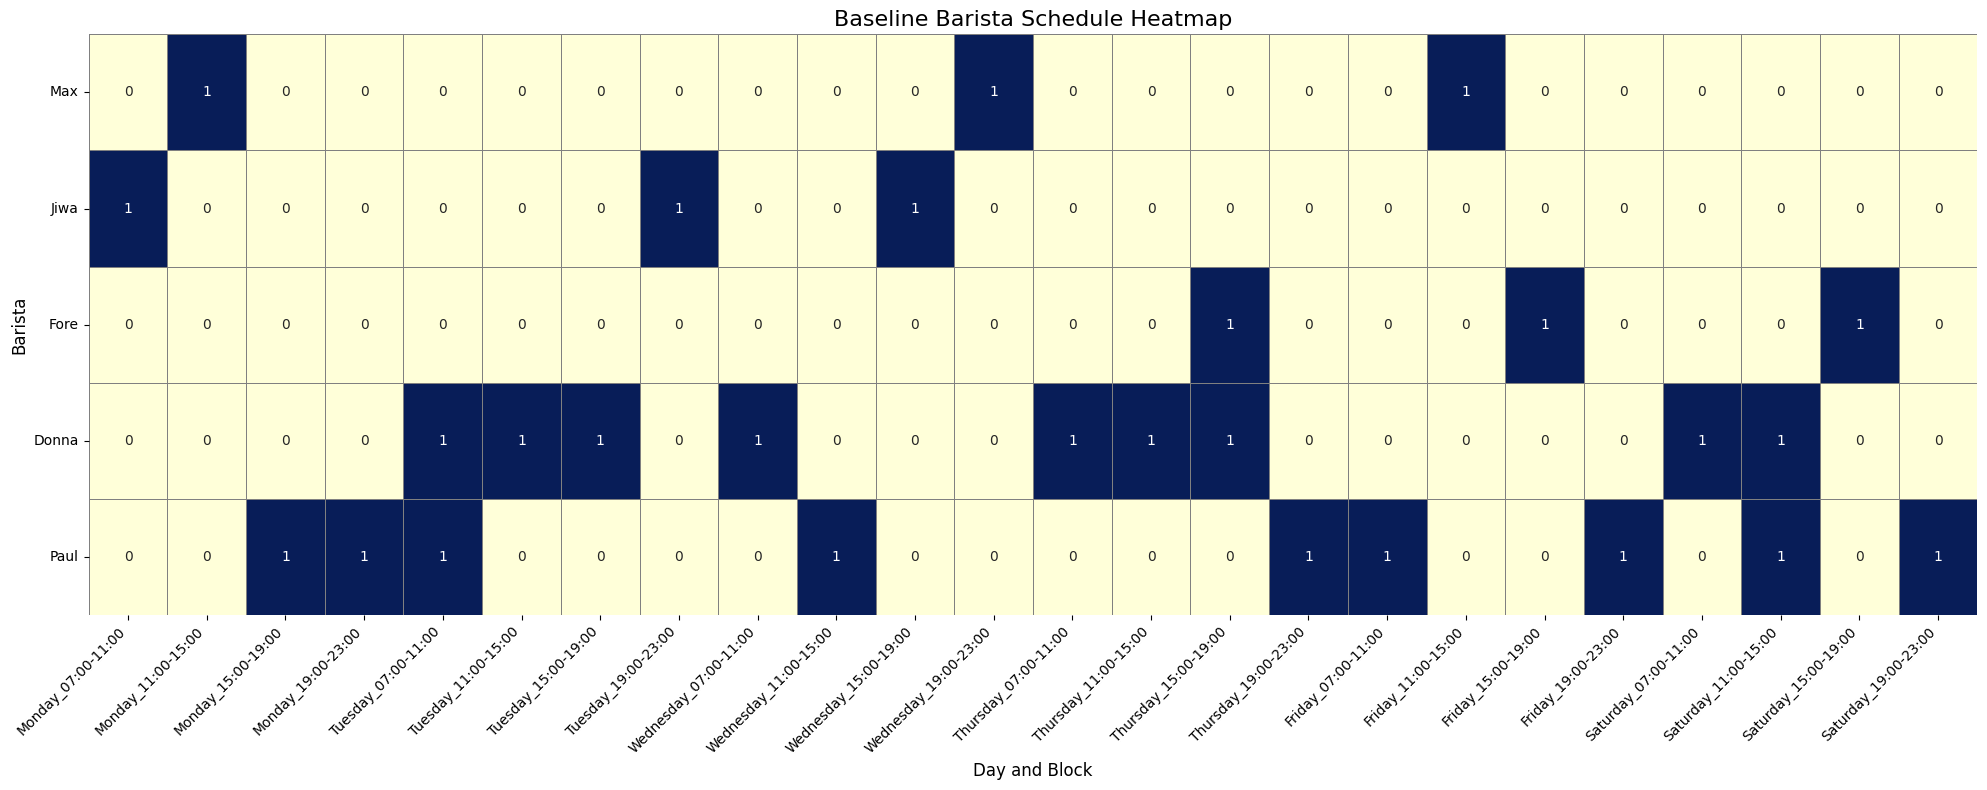

Baseline Heatmap generated and displayed successfully.


In [294]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare heatmap data for the Baseline model
columns = [f"{DAY_NAME[d]}_{BLOCK_NAME[b]}" for d in days for b in blocks]
heatmap_data_baseline = pd.DataFrame(0, index=baristas, columns=columns)

for d in days:
    for b in blocks:
        if d in base_sched and b in base_sched[d]:
            for barista in base_sched[d][b]:
                col_name = f"{DAY_NAME[d]}_{BLOCK_NAME[b]}"
                if barista in heatmap_data_baseline.index and col_name in heatmap_data_baseline.columns:
                    heatmap_data_baseline.loc[barista, col_name] = 1

plt.figure(figsize=(20, 8))
sns.heatmap(heatmap_data_baseline, annot=True, cmap="YlGnBu", cbar=False, linewidths=.5, linecolor='gray')
plt.title('Baseline Barista Schedule Heatmap', fontsize=16)
plt.xlabel('Day and Block', fontsize=12)
plt.ylabel('Barista', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Baseline Heatmap generated and displayed successfully.")

In [295]:
baseline_weekly_summary_data = []
for o in baristas:
    baseline_weekly_summary_data.append({
        "Barista": o,
        "Weekly Hours": base_hours[o],
        "Cost Per Hour (IDR)": f"{cost[o]:,.2f}",
        "Weekly Cost (IDR)": f"{barista_weekly_cost_base[o]:,.2f}"
    })

baseline_weekly_summary_df = pd.DataFrame(baseline_weekly_summary_data)
display(baseline_weekly_summary_df)

,Barista,Weekly Hours,Cost Per Hour (IDR),Weekly Cost (IDR)
0,Max,12,"50,000.00","600,000.00"
1,Jiwa,12,"50,000.00","600,000.00"
2,Fore,12,"50,000.00","600,000.00"
3,Donna,36,"150,000.00","5,400,000.00"
4,Paul,36,"150,000.00","5,400,000.00"


In [296]:
def main():
    print("CW5 MILP models using PuLP (CBC).")

# Optimal Cost is used as the baseline

Scenario 1: close at 19:00 (remove block 4)

In [297]:
sA_model, status_sA, sA_cost, sA_hours, sA_barista_weekly_cost, sA_sched = solve_close_at_19()
print_summary("SCENARIO A — CLOSE AT 19:00 (remove block 4)", status_sA, sA_cost, sA_hours, sA_sched)
save_schedule_csv("results/close19_schedule.csv", sA_hours, sA_sched, days, [1, 2, 3])  # only 3 blocks


SCENARIO A — CLOSE AT 19:00 (remove block 4)
Solver status: Optimal
Total weekly cost (IDR): 12,600,000

Weekly hours per barista:
  - Max   : 12 hours

Daily × Block schedule:
  - Jiwa  : 12 hours

Daily × Block schedule:
  - Fore  : 12 hours

Daily × Block schedule:
  - Donna : 36 hours

Daily × Block schedule:
  - Paul  : 36 hours

Daily × Block schedule:
  Monday:
    [07:00-11:00] → Max
    [11:00-15:00] → Donna
    [15:00-19:00] → Jiwa, Paul
  Tuesday:
    [07:00-11:00] → Donna, Paul
    [11:00-15:00] → Donna
    [15:00-19:00] → Max, Donna, Paul
  Wednesday:
    [07:00-11:00] → Donna
    [11:00-15:00] → Jiwa, Paul
    [15:00-19:00] → Paul
  Thursday:
    [07:00-11:00] → Fore
    [11:00-15:00] → Paul
    [15:00-19:00] → Paul
  Friday:
    [07:00-11:00] → Fore, Donna, Paul
    [11:00-15:00] → Donna
    [15:00-19:00] → Donna, Paul
  Saturday:
    [07:00-11:00] → Jiwa
    [11:00-15:00] → Fore, Donna
    [15:00-19:00] → Max



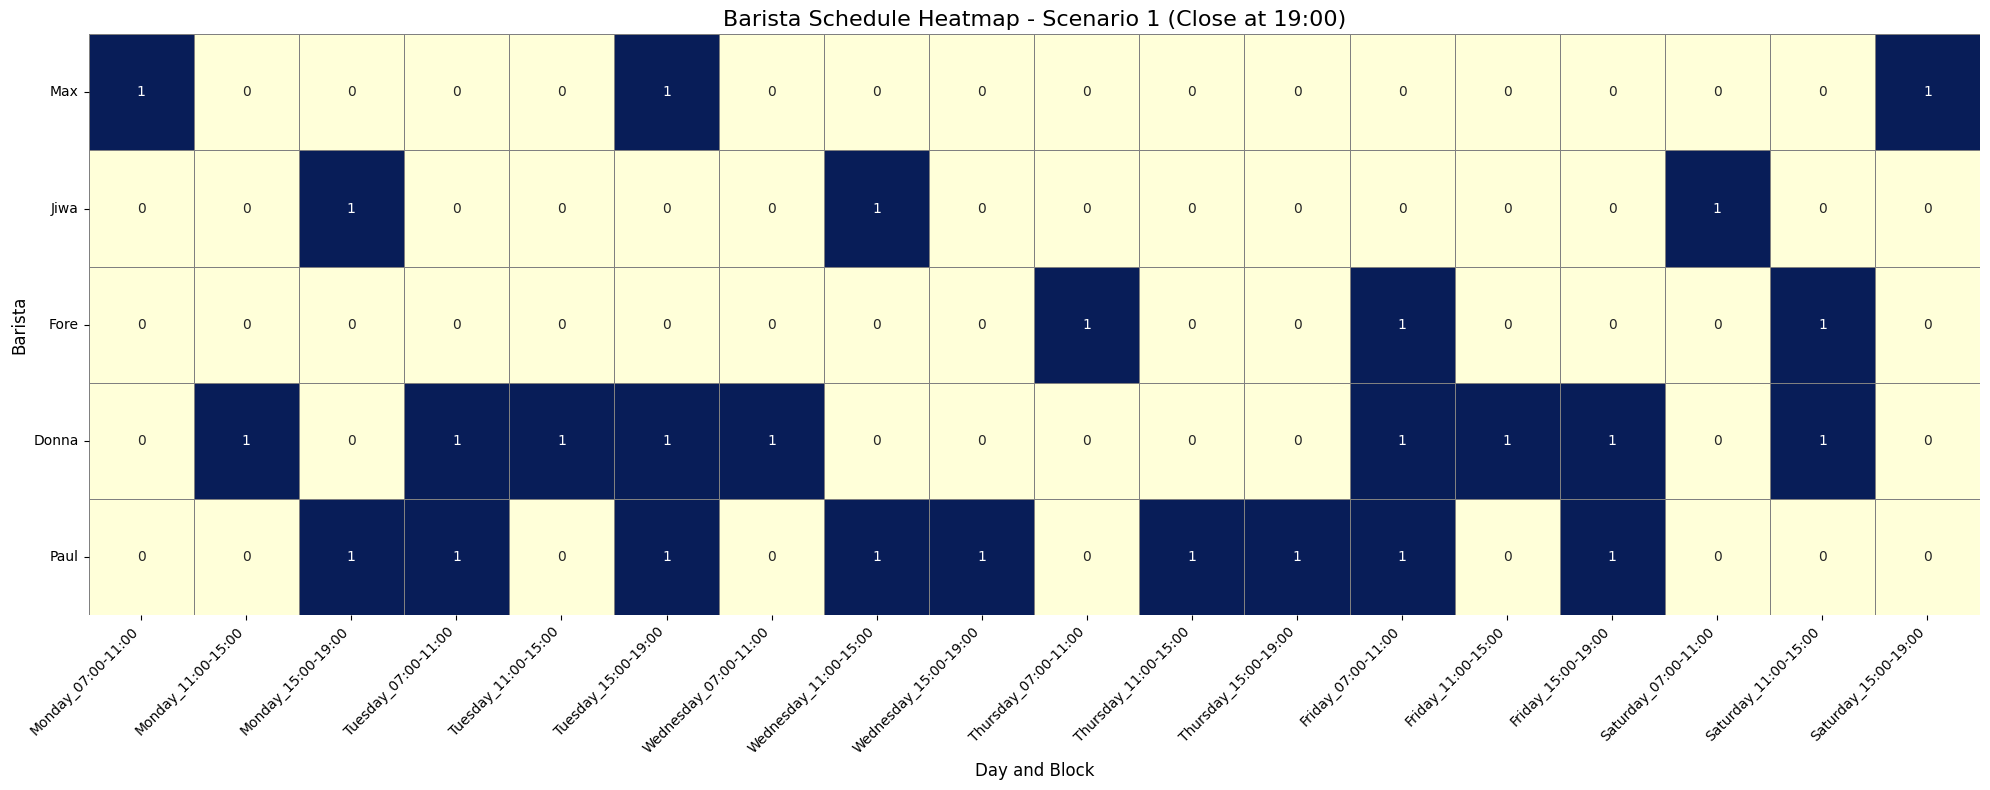

Heatmap for Scenario 1 generated and displayed successfully.


In [298]:
plt.figure(figsize=(20, 8))
sns.heatmap(heatmap_data_scenario_1, annot=True, cmap="YlGnBu", cbar=False, linewidths=.5, linecolor='gray')
plt.title('Barista Schedule Heatmap - Scenario 1 (Close at 19:00)', fontsize=16)
plt.xlabel('Day and Block', fontsize=12)
plt.ylabel('Barista', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Heatmap for Scenario 1 generated and displayed successfully.")

In [299]:
import pandas as pd
from IPython.display import display

# Prepare data for the weekly summary table for the Fairness model
fairness_weekly_summary_data = []
for o in baristas:
    fairness_weekly_summary_data.append({
        "Barista": o,
        "Weekly Hours": hours_by_barista_fairness[o],
        "Cost Per Hour (IDR)": f"{cost[o]:,.2f}",
        "Weekly Cost (IDR)": f"{barista_weekly_cost_fairness[o]:,.2f}"
    })

fairness_weekly_summary_df = pd.DataFrame(fairness_weekly_summary_data)

print("### Weekly Barista Summary - Fairness Model")
display(fairness_weekly_summary_df)

### Weekly Barista Summary - Fairness Model


,Barista,Weekly Hours,Cost Per Hour (IDR),Weekly Cost (IDR)
0,Max,12,"50,000.00","600,000.00"
1,Jiwa,16,"50,000.00","800,000.00"
2,Fore,12,"50,000.00","600,000.00"
3,Donna,36,"150,000.00","5,400,000.00"
4,Paul,36,"150,000.00","5,400,000.00"


In [300]:
# Re-defining core data and parameters
baristas=["Max","Jiwa","Fore","Donna","Paul"]
days= list(range(1,7))
blocks=list(range(1,5))
H=4
cost={"Max":50000,"Jiwa":50000,"Fore":50000,"Donna":150000,"Paul":150000}
etype={"Max":"P","Jiwa":"P","Fore":"P","Donna":"F","Paul":"F"}
minweekly={"Max":12,"Jiwa":12,"Fore":12,"Donna":36,"Paul":36}
avail={("Max",1):8,("Max",2):8,("Max",3):8,("Max",4):0,("Max",5):8,("Max",6):4,("Max",7):4,("Jiwa",1):4,("Jiwa",2):4,("Jiwa",3):8,("Jiwa",4):8,("Jiwa",5):0,("Jiwa",6):4,("Jiwa",7):0,("Fore",1):8,("Fore",2):0,("Fore",3):8,("Fore",4):8,("Fore",5):8,("Fore",6):8,("Fore",7):0,("Donna",1):12,("Donna",2):12,("Donna",3):12,("Donna",4):12,("Donna",5):12,("Donna",6):12,("Donna",7):8,("Paul",1):12,("Paul",2):8,("Paul",3):12,("Paul",4):12,("Paul",5):8,("Paul",6):12,("Paul",7):12,}
DAY_NAME={1:"Monday",2:"Tuesday",3:"Wednesday",4:"Thursday",5:"Friday",6:"Saturday",7:"Sunday"}
BLOCK_NAME={1:"07:00-11:00",2:"11:00-15:00",3:"15:00-19:00",4:"19:00-23:00"}

minWeekly_default = minweekly
allow_blocks = {d: set(blocks) for d in days}

print("All core data and parameters have been re-defined globally.")

All core data and parameters have been re-defined globally.


In [301]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define blocks for this scenario (1, 2, 3)
scenario_blocks = [1, 2, 3]

# Prepare columns for the heatmap, considering only scenario_blocks
columns_scenario_1 = [f"{DAY_NAME[d]}_{BLOCK_NAME[b]}" for d in days for b in scenario_blocks]
heatmap_data_scenario_1 = pd.DataFrame(0, index=baristas, columns=columns_scenario_1)

# Populate heatmap data using sA_sched
for d in days:
    for b in scenario_blocks:
        if d in sA_sched and b in sA_sched[d]:
            for barista in sA_sched[d][b]:
                col_name = f"{DAY_NAME[d]}_{BLOCK_NAME[b]}"
                if barista in heatmap_data_scenario_1.index and col_name in heatmap_data_scenario_1.columns:
                    heatmap_data_scenario_1.loc[barista, col_name] = 1

print("Heatmap data for Scenario 1 prepared successfully.")

Heatmap data for Scenario 1 prepared successfully.


 Scenario B: part-time weekly minimum = 16 hours

In [302]:
sB_model, (status_sB, sB_objective_val, sB_hours, sB_barista_weekly_cost, sB_sched, sB_monetary_total_cost) = solve_pt_min16()
print_summary("SCENARIO B — PART-TIME MIN = 16 HOURS", status_sB, sB_monetary_total_cost, sB_hours, sB_sched)
save_schedule_csv("results/ptmin16_schedule.csv", sB_hours, sB_sched, days, blocks)


SCENARIO B — PART-TIME MIN = 16 HOURS
Solver status: Optimal
Total weekly cost (IDR): 13,200,000

Weekly hours per barista:
  - Max   : 16 hours

Daily × Block schedule:
  - Jiwa  : 16 hours

Daily × Block schedule:
  - Fore  : 16 hours

Daily × Block schedule:
  - Donna : 36 hours

Daily × Block schedule:
  - Paul  : 36 hours

Daily × Block schedule:
  Monday:
    [07:00-11:00] → Jiwa
    [11:00-15:00] → Max
    [15:00-19:00] → Paul
    [19:00-23:00] → Paul
  Tuesday:
    [07:00-11:00] → Donna, Paul
    [11:00-15:00] → Donna
    [15:00-19:00] → Max, Donna
    [19:00-23:00] → Jiwa
  Wednesday:
    [07:00-11:00] → Donna
    [11:00-15:00] → Paul
    [15:00-19:00] → Jiwa
    [19:00-23:00] → Max, Jiwa
  Thursday:
    [07:00-11:00] → Donna
    [11:00-15:00] → Donna
    [15:00-19:00] → Fore, Donna
    [19:00-23:00] → Paul
  Friday:
    [07:00-11:00] → Paul
    [11:00-15:00] → Max
    [15:00-19:00] → Fore
    [19:00-23:00] → Fore, Paul
  Saturday:
    [07:00-11:00] → Donna
    [11:00-15:00] 

In [303]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

columns = [f"{DAY_NAME[d]}_{BLOCK_NAME[b]}" for d in days for b in blocks]
heatmap_data_scenarioB = pd.DataFrame(0, index=baristas, columns=columns)

for d in days:
    for b in blocks:
        if d in sB_sched and b in sB_sched[d]:
            for barista in sB_sched[d][b]:
                col_name = f"{DAY_NAME[d]}_{BLOCK_NAME[b]}"
                if barista in heatmap_data_scenarioB.index and col_name in heatmap_data_scenarioB.columns:
                    heatmap_data_scenarioB.loc[barista, col_name] = 1

print("Heatmap data for Scenario B prepared successfully.")

Heatmap data for Scenario B prepared successfully.


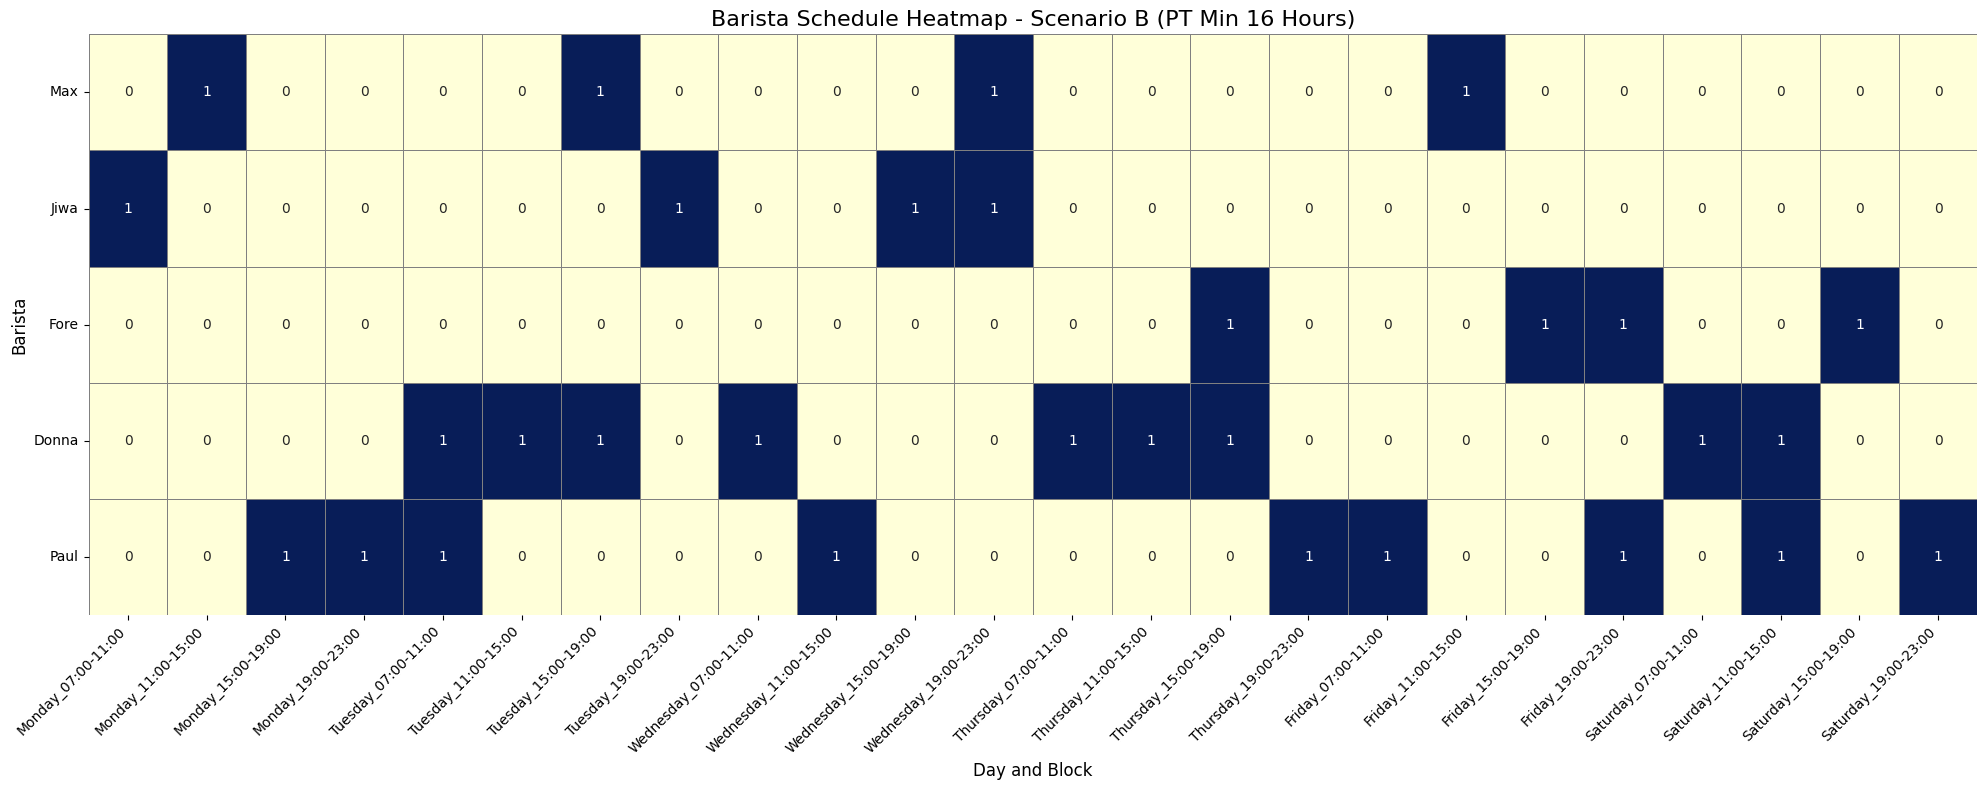

Heatmap for Scenario B generated and displayed successfully.


In [304]:
plt.figure(figsize=(20, 8))
sns.heatmap(heatmap_data_scenarioB, annot=True, cmap="YlGnBu", cbar=False, linewidths=.5, linecolor='gray')
plt.title('Barista Schedule Heatmap - Scenario B (PT Min 16 Hours)', fontsize=16)
plt.xlabel('Day and Block', fontsize=12)
plt.ylabel('Barista', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Heatmap for Scenario B generated and displayed successfully.")

In [305]:
# Table 2: Detailed Daily Schedule for Scenario B
schedule_table_data_scenarioB = {}
for d in sorted(sB_sched.keys()):
    day_name = DAY_NAME[d]
    schedule_table_data_scenarioB[day_name] = {}
    for b in sorted(blocks):
        block_name = BLOCK_NAME[b]
        assigned_baristas = ", ".join(sB_sched[d].get(b, [])) if sB_sched[d].get(b) else "(none)"
        schedule_table_data_scenarioB[day_name][block_name] = assigned_baristas

scenarioB_schedule_df = pd.DataFrame(schedule_table_data_scenarioB).T.fillna("") # Transpose and fill empty for readability
print("\n### Daily Schedule Breakdown - Scenario B")
display(scenarioB_schedule_df)


### Daily Schedule Breakdown - Scenario B


,07:00-11:00,11:00-15:00,15:00-19:00,19:00-23:00
Monday,Jiwa,Max,Paul,Paul
Tuesday,"Donna, Paul",Donna,"Max, Donna",Jiwa
Wednesday,Donna,Paul,Jiwa,"Max, Jiwa"
Thursday,Donna,Donna,"Fore, Donna",Paul
Friday,Paul,Max,Fore,"Fore, Paul"
Saturday,Donna,"Donna, Paul",Fore,Paul


 Fairness model (≤ 102% of baseline cost)

In [306]:
model_fairness, (status_fairness, fairness_gap_val, hours_by_barista_fairness, barista_weekly_cost_fairness, schedule_fairness, monetary_total_cost_fairness) = solve_fairness(total_cost)

print_summary("Fairness Barista Schedule", status_fairness, monetary_total_cost_fairness, hours_by_barista_fairness, schedule_fairness)
print(f"Fairness Gap (Hmax - Hmin): {fairness_gap_val}")


Fairness Barista Schedule
Solver status: Optimal
Total weekly cost (IDR): 12,800,000

Weekly hours per barista:
  - Max   : 12 hours

Daily × Block schedule:
  - Jiwa  : 16 hours

Daily × Block schedule:
  - Fore  : 12 hours

Daily × Block schedule:
  - Donna : 36 hours

Daily × Block schedule:
  - Paul  : 36 hours

Daily × Block schedule:
  Monday:
    [07:00-11:00] → Paul
    [11:00-15:00] → Jiwa
    [15:00-19:00] → Max
    [19:00-23:00] → Paul
  Tuesday:
    [07:00-11:00] → Max
    [11:00-15:00] → Donna
    [15:00-19:00] → Paul
    [19:00-23:00] → Donna
  Wednesday:
    [07:00-11:00] → Donna
    [11:00-15:00] → Donna
    [15:00-19:00] → Jiwa
    [19:00-23:00] → Paul
  Thursday:
    [07:00-11:00] → Fore
    [11:00-15:00] → Jiwa, Paul
    [15:00-19:00] → Donna
    [19:00-23:00] → Paul
  Friday:
    [07:00-11:00] → Donna
    [11:00-15:00] → Max
    [15:00-19:00] → Donna
    [19:00-23:00] → Paul
  Saturday:
    [07:00-11:00] → Jiwa, Fore
    [11:00-15:00] → Donna, Paul
    [15:00-19:00

In [307]:
columns = [f"{DAY_NAME[d]}_{BLOCK_NAME[b]}" for d in days for b in blocks]
heatmap_data_fairness = pd.DataFrame(0, index=baristas, columns=columns)

for d in days:
    for b in blocks:
        if d in schedule_fairness and b in schedule_fairness[d]:
            for barista in schedule_fairness[d][b]:
                col_name = f"{DAY_NAME[d]}_{BLOCK_NAME[b]}"
                if barista in heatmap_data_fairness.index and col_name in heatmap_data_fairness.columns:
                    heatmap_data_fairness.loc[barista, col_name] = 1

print("Fairness Heatmap data prepared successfully.")

Fairness Heatmap data prepared successfully.


In [308]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare heatmap data for the Fairness model
columns = [f"{DAY_NAME[d]}_{BLOCK_NAME[b]}" for d in days for b in blocks]
heatmap_data_fairness = pd.DataFrame(0, index=baristas, columns=columns)

for d in days:
    for b in blocks:
        if d in schedule_fairness and b in schedule_fairness[d]:
            for barista in schedule_fairness[d][b]:
                col_name = f"{DAY_NAME[d]}_{BLOCK_NAME[b]}"
                if barista in heatmap_data_fairness.index and col_name in heatmap_data_fairness.columns:
                    heatmap_data_fairness.loc[barista, col_name] = 1

print("Fairness Heatmap data prepared successfully.")

Fairness Heatmap data prepared successfully.


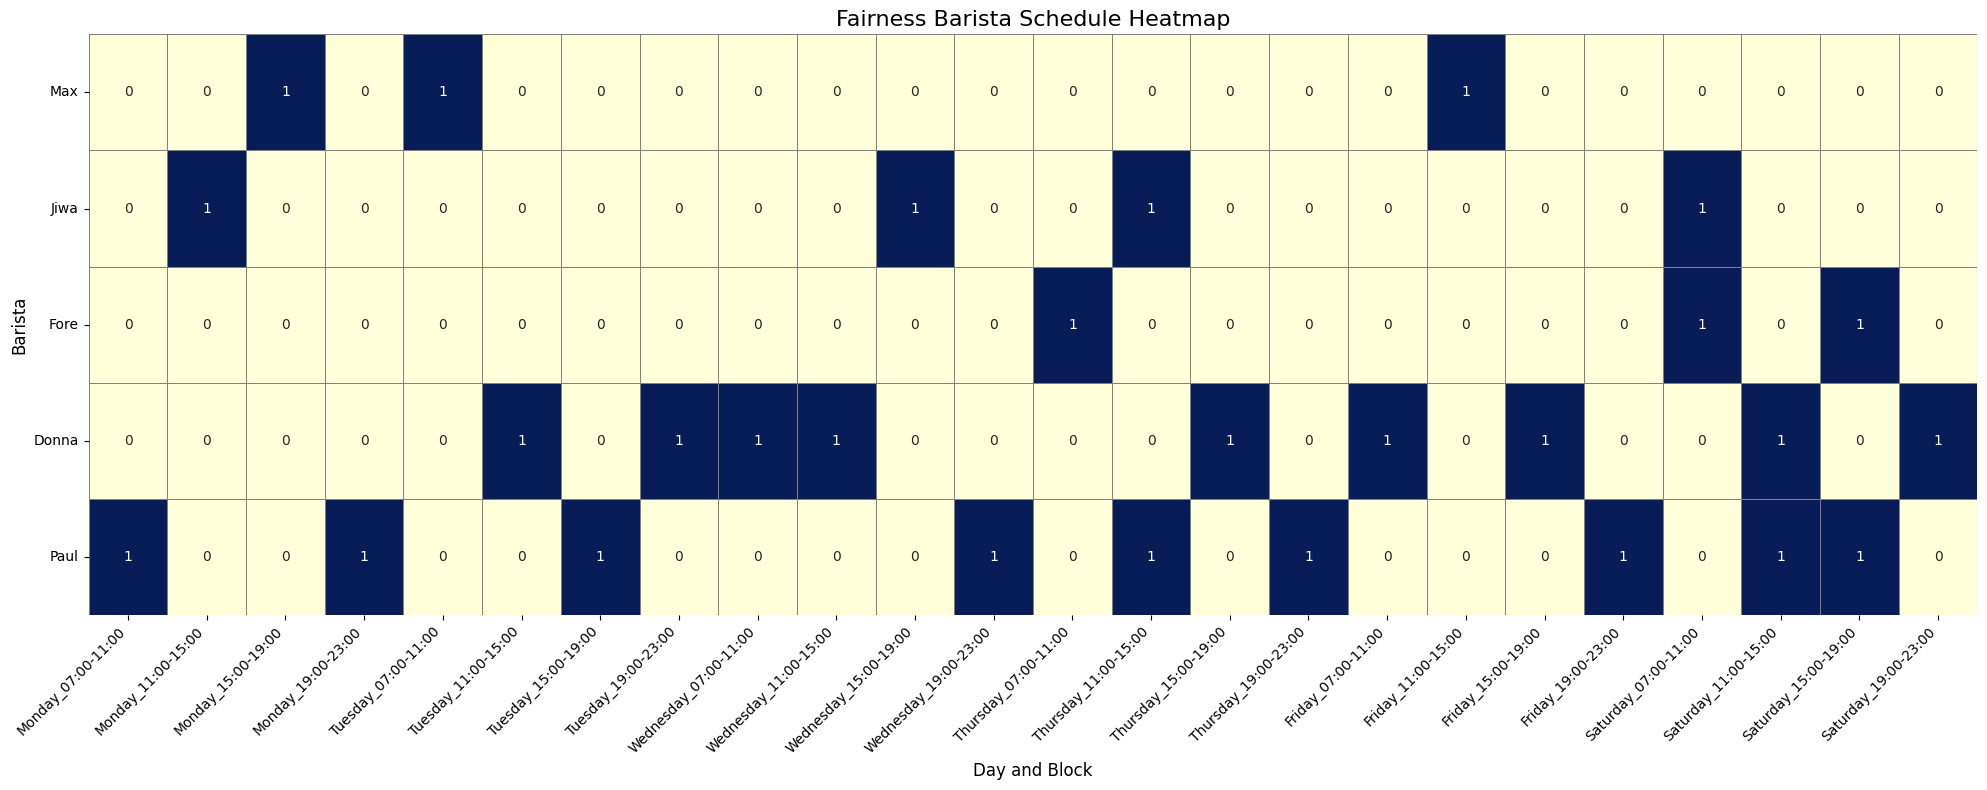

Fairness Heatmap generated and displayed successfully.


In [309]:
# Display the Fairness Heatmap
plt.figure(figsize=(20, 8))
sns.heatmap(heatmap_data_fairness, annot=True, cmap="YlGnBu", cbar=False, linewidths=.5, linecolor='gray')
plt.title('Fairness Barista Schedule Heatmap', fontsize=16)
plt.xlabel('Day and Block', fontsize=12)
plt.ylabel('Barista', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Fairness Heatmap generated and displayed successfully.")

In [310]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare heatmap data for the Fairness model
columns = [f"{DAY_NAME[d]}_{BLOCK_NAME[b]}" for d in days for b in blocks]
heatmap_data_fairness = pd.DataFrame(0, index=baristas, columns=columns)

for d in days:
    for b in blocks:
        if d in schedule_fairness and b in schedule_fairness[d]:
            for barista in schedule_fairness[d][b]:
                col_name = f"{DAY_NAME[d]}_{BLOCK_NAME[b]}"
                if barista in heatmap_data_fairness.index and col_name in heatmap_data_fairness.columns:
                    heatmap_data_fairness.loc[barista, col_name] = 1

print("Fairness Heatmap data prepared successfully.")

Fairness Heatmap data prepared successfully.


Skill Variant

## Define Skill Data



In [311]:
barista_skills = {
    "Max": ["Coffee_Expert", "Latte_Art", "Customer_Service"],
    "Jiwa": ["Coffee_Expert", "Customer_Service"],
    "Fore": ["Latte_Art", "Customer_Service"],
    "Donna": ["Coffee_Expert", "Latte_Art", "Customer_Service", "Manager"],
    "Paul": ["Coffee_Expert", "Customer_Service", "Manager"]
}

print("barista_skills dictionary created successfully.")

barista_skills dictionary created successfully.


In [312]:
required_skills_per_block = {}
for d in days:
    for b in blocks:
        if b == 1: # Morning block
            required_skills_per_block[(d, b)] = ['Coffee_Expert', 'Customer_Service']
        elif b == 2: # Lunch block
            required_skills_per_block[(d, b)] = ['Coffee_Expert', 'Latte_Art', 'Customer_Service']
        elif b == 3: # Afternoon block, potentially busy, might need a manager
            if d in [6, 7]: # Weekend, likely busier
                required_skills_per_block[(d, b)] = ['Coffee_Expert', 'Latte_Art', 'Customer_Service', 'Manager']
            else:
                required_skills_per_block[(d, b)] = ['Coffee_Expert', 'Customer_Service']
        elif b == 4: # Evening block, might need a manager for closing
            if d in [6, 7]: # Weekend, might be busier until close
                required_skills_per_block[(d, b)] = ['Coffee_Expert', 'Customer_Service', 'Manager']
            else:
                required_skills_per_block[(d, b)] = ['Coffee_Expert', 'Customer_Service']

print("required_skills_per_block dictionary created successfully.")

required_skills_per_block dictionary created successfully.


In [313]:
def build_skill_model(baristas, days, blocks, H, cost, avail, etype, minWeekly, barista_skills, required_skills_per_block, name="SkillVariant"):
    """
    Build skill variant staffing model with skill coverage constraints.
    """
    model = pl.LpProblem(name, pl.LpMinimize)

    # 3. Define binary decision variables 'y'
    y = pl.LpVariable.dicts("Assign",
                            ((o, d, b) for o in baristas for d in days for b in blocks),
                            lowBound=0, upBound=1, cat='Binary')

    # 4a. Coverage constraints
    for d in days:
        for b in blocks:
            model += pl.lpSum(y[(o, d, b)] for o in baristas) >= 1, f"cover_d{d}_b{b}"

    # 4b & 4c. Per-day availability (hours) and contractual block caps constraints
    for o in baristas:
        for d in days:
            # availability limit
            if (o, d) in avail: # Check if (o, d) exists in avail
                model += H * pl.lpSum(y[(o, d, b)] for b in blocks) <= avail[(o, d)], f"avail_{o}_{d}"
            else:
                # Handle cases where availability for (o,d) is not explicitly defined, e.g., assume 0 or maximum possible
                # For now, let's assume if not in avail, then 0, which means no shifts for that day.
                # If you want to allow full availability, you'd need a different logic.
                model += H * pl.lpSum(y[(o, d, b)] for b in blocks) <= 0, f"avail_{o}_{d}"

            # contractual daily block cap
            cap = 2 if etype[o] == "P" else 3
            model += pl.lpSum(y[(o, d, b)] for b in blocks) <= cap, f"blockCap_{o}_{d}"

    # 4d. Weekly minimum hours constraints
    for o in baristas:
        model += H * pl.lpSum(y[(o, d, b)] for d in days for b in blocks) >= minWeekly[o], f"minweekly_{o}"

    # 4e. Skill coverage constraints
    for d in days:
        for b in blocks:
            if (d, b) in required_skills_per_block: # Check if there are required skills for this block
                for skill in required_skills_per_block[(d, b)]:
                    # Ensure at least one barista with the required skill is assigned to the block
                    model += pl.lpSum(y[(o, d, b)] for o in baristas if skill in barista_skills.get(o, [])) >= 1, f"skill_cover_{skill}_d{d}_b{b}"

    # 5. Objective function: Minimize total cost
    model += pl.lpSum(y[(o, d, b)] * H * cost[o] for o in baristas for d in days for b in blocks), "Total_Cost"

    # 6. Return the constructed model, y, and blocks
    return model, y, blocks


def solve_skill():
    """
    Solves the skill variant optimization model.
    """
    # 7. Call build_skill_model with globally defined parameters
    model, y, allow_blocks_skill = build_skill_model(
        baristas, days, blocks, H, cost, avail, etype, minWeekly_default, barista_skills, required_skills_per_block, name="SkillVariant"
    )

    # 8. Solve the model
    solver = pl.PULP_CBC_CMD(msg=True, timeLimit=300)
    model.solve(solver)

    # 9. Call extract_results function
    status, objective_val_placeholder, hours_by_barista, barista_weekly_cost, schedule, monetary_total_cost = extract_results(model, y, baristas, days, blocks, allow_blocks_skill, H, cost)

    # 10. The solve_skill function should return the status, monetary_total_cost, hours_by_barista, barista_weekly_cost, and schedule.
    return status, monetary_total_cost, hours_by_barista, barista_weekly_cost, schedule

print("build_skill_model and solve_skill functions defined successfully.")

build_skill_model and solve_skill functions defined successfully.
